In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
df = pd.read_csv("../.data/tute1.csv")

In [4]:
df.head(5)

,Quarter,Sales,AdBudget,GDP
0,1981-03-01,1020.2,659.2,251.8
1,1981-06-01,889.2,589.0,290.9
2,1981-09-01,795.0,512.5,290.8
3,1981-12-01,1003.9,614.1,292.4
4,1982-03-01,1057.7,647.2,279.1


In [5]:
df["datetime"] = pd.to_datetime(df["Quarter"])
df.set_index("datetime", inplace=True)
df.drop(columns=["Quarter"], inplace=True)

In [6]:
df.columns

Index(['Sales', 'AdBudget', 'GDP'], dtype='object')

<Axes: xlabel='datetime'>

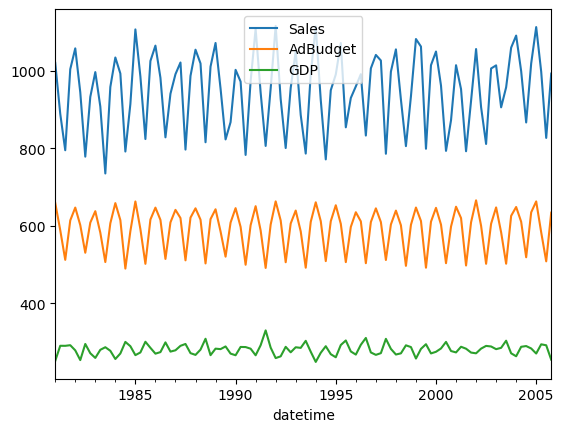

In [7]:
df.plot()

<Axes: xlabel='Sales', ylabel='AdBudget'>

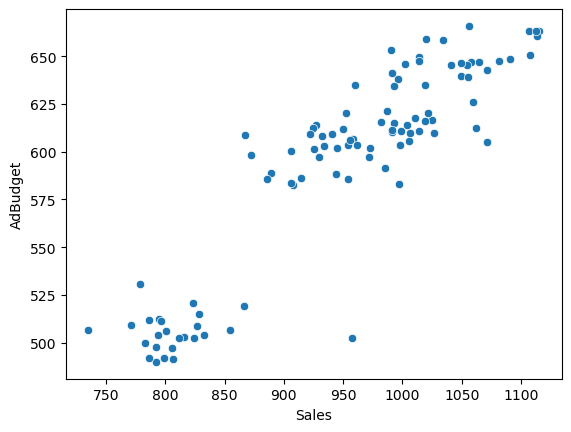

In [8]:
sns.scatterplot(df, x="Sales", y="AdBudget")

In [9]:
df.dtypes

Sales       float64
AdBudget    float64
GDP         float64
dtype: object

In [10]:
# pearson correlation
correlation_matrix = df.corr(method="pearson")
print(correlation_matrix)

             Sales  AdBudget       GDP
Sales     1.000000  0.907765 -0.635961
AdBudget  0.907765  1.000000 -0.768860
GDP      -0.635961 -0.768860  1.000000


0.9999999999999999
-0.07668071536200897
-0.8289126059616927
-0.05925025572984938
0.9653189658717932
-0.09251958591434511
-0.822410703394147
-0.05743743149560663
0.9682404794704401
-0.08778253145118874


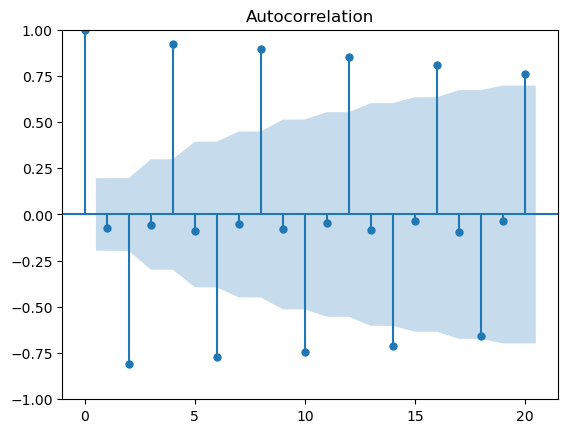

In [11]:
# Assuming you have a pandas Series called 'series' with your data
for lag in np.arange(0, 10):
    print(df["AdBudget"].autocorr(lag=lag))
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Assuming df["AdBudget"] is your series
plot_acf(df["AdBudget"])
plt.show()




# EX 2
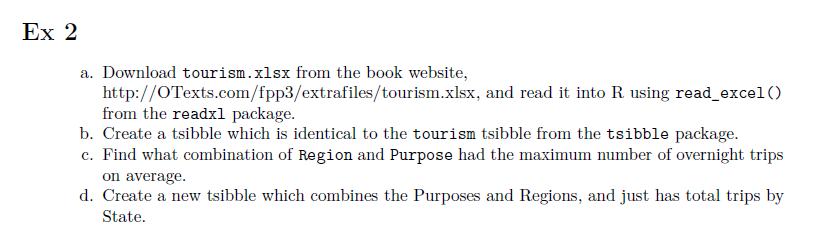

In [12]:
columns = ["Quarter","Region","State","Purpose","Trips"]

df = pd.read_excel('../.data/tourism.xlsx', sheet_name="Sheet1", names=columns)

In [13]:
df.head()

,Quarter,Region,State,Purpose,Trips
0,1998-04-01,Adelaide,South Australia,Business,109.987316
1,1998-07-01,Adelaide,South Australia,Business,166.034687
2,1998-10-01,Adelaide,South Australia,Business,127.160464
3,1999-01-01,Adelaide,South Australia,Business,137.448533
4,1999-04-01,Adelaide,South Australia,Business,199.912586


C:\Users\Max\AppData\Local\Temp\ipykernel_24972\2058404067.py:2: FutureWarning: The provided callable <function mean at 0x0000024C81C3C860> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = df.pivot_table(values='Trips', index='Region', columns='Purpose', aggfunc=np.mean)


Purpose                       Business     Holiday      Other    Visiting
Region                                                                   
Adelaide                    155.786773  156.543437  56.563450  205.193667
Adelaide Hills                2.664236   10.467276   1.404931   14.202530
Alice Springs                14.570929   31.887332   3.405408    6.751449
Australia's Coral Coast      33.120125  113.460316   6.243950   36.763332
Australia's Golden Outback   71.289100   61.817661   6.466019   48.145637
...                                ...         ...        ...         ...
Western Grampians            13.887055   24.635034   3.003753   28.467205
Whitsundays                  17.084744   78.700449   2.304352   18.250696
Wilderness West               4.862438   31.736328   0.478268    2.963302
Wimmera                       5.492122    9.601879   1.146237   14.879986
Yorke Peninsula               6.892481   80.088485   1.885884   28.146552

[76 rows x 4 columns]


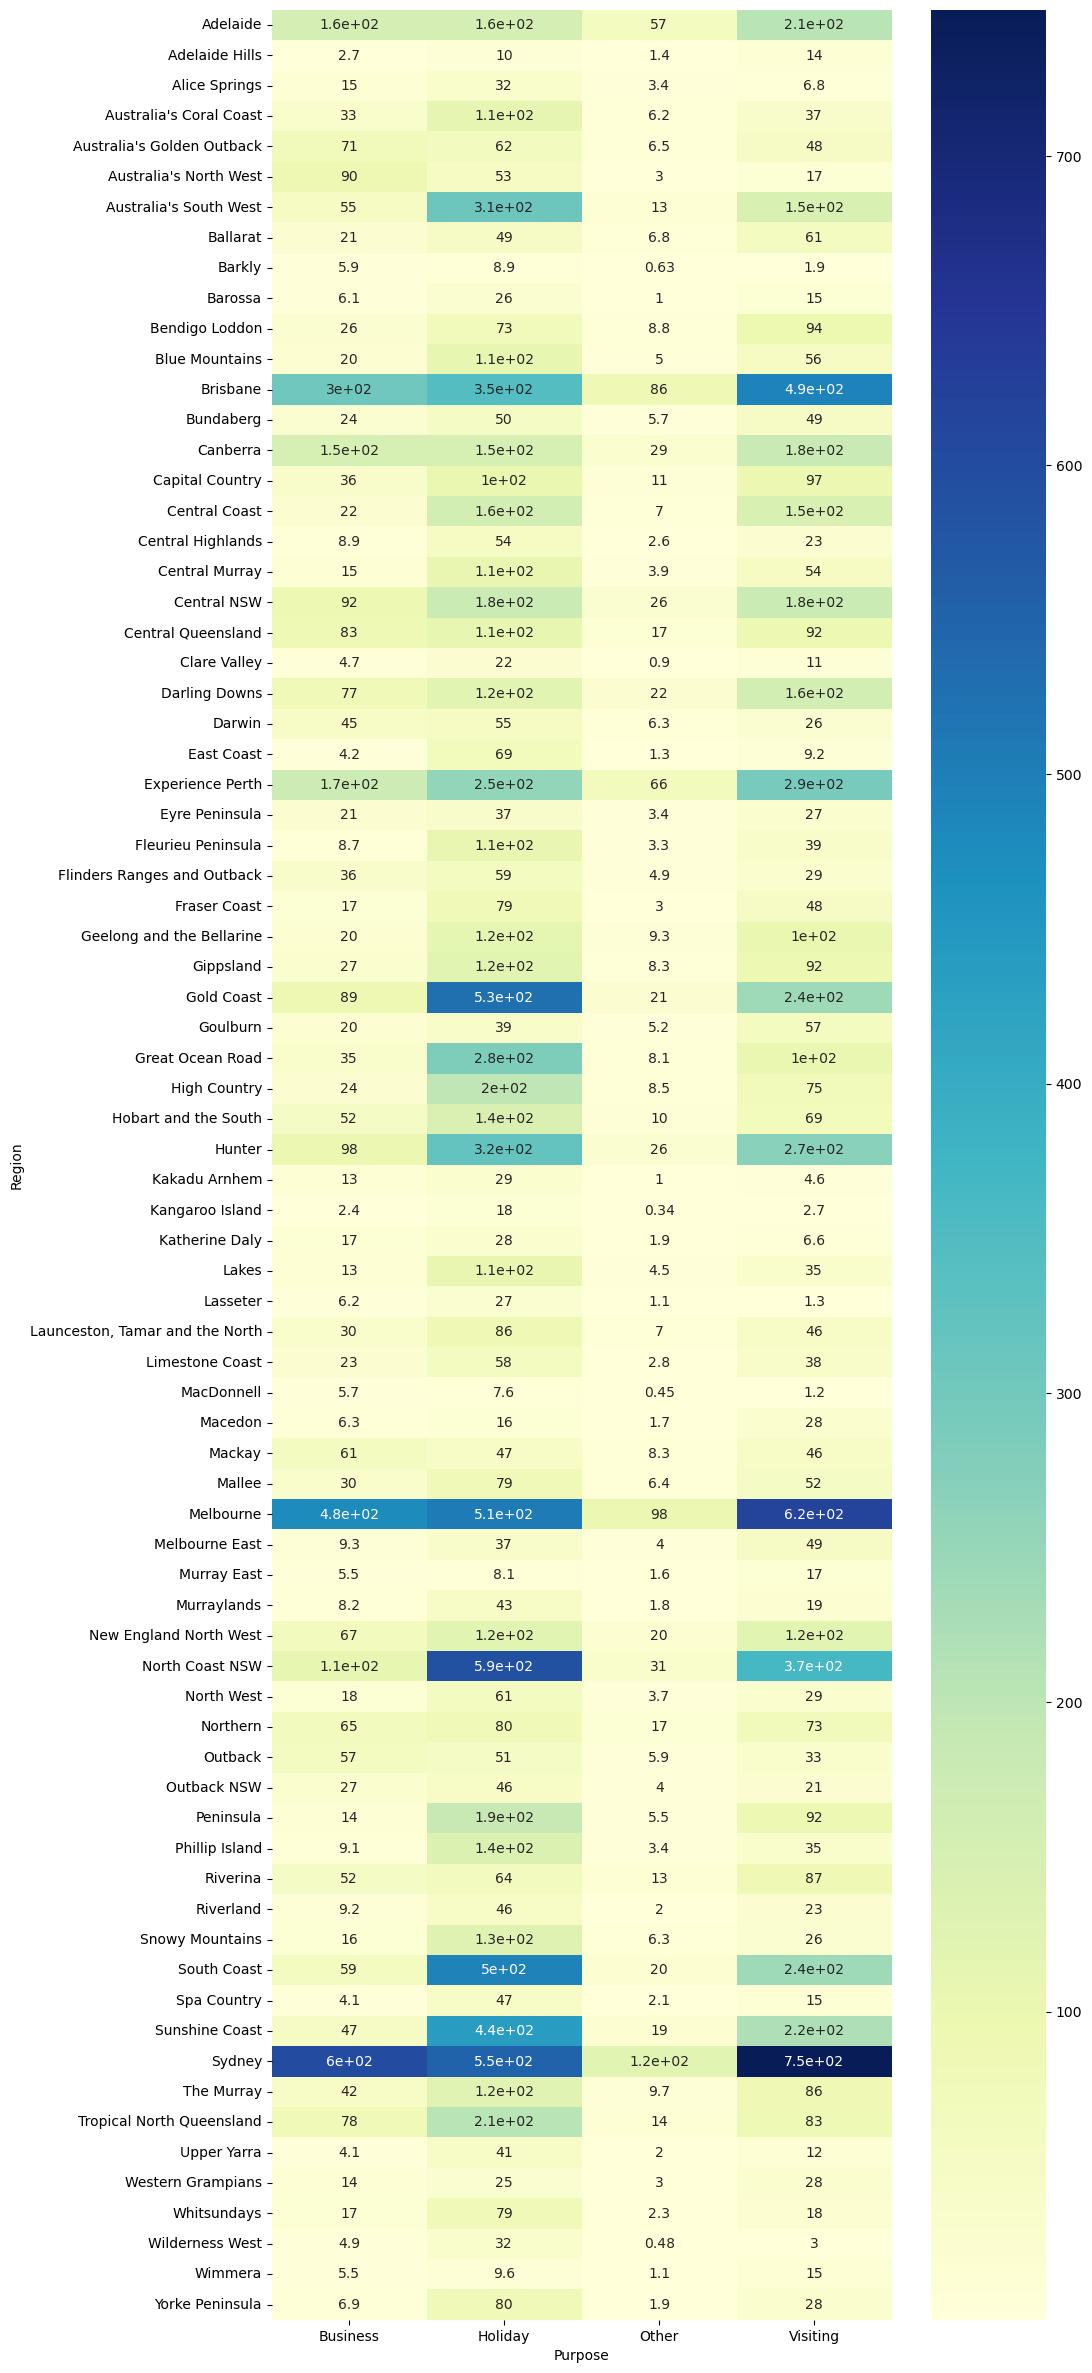

The maximum value is 747.2699681612501 at ('Sydney', 'Visiting')


In [14]:
# Create a pivot table
pivot_table = df.pivot_table(values='Trips', index='Region', columns='Purpose', aggfunc=np.mean)

print(pivot_table)
plt.figure(figsize=(10, 30))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True)
plt.show()
# Stack the DataFrame and get the index of the maximum value
max_index = pivot_table.stack().idxmax()

# Get the maximum value
max_value = pivot_table.loc[max_index]

print(f"The maximum value is {max_value} at {max_index}")


In [15]:
state_df = df.groupby('State')['Trips'].sum().reset_index()
state_df.head()

,State,Trips
0,ACT,41006.585207
1,New South Wales,557367.430368
2,Northern Territory,28613.683011
3,Queensland,386642.911752
4,South Australia,118016.270464


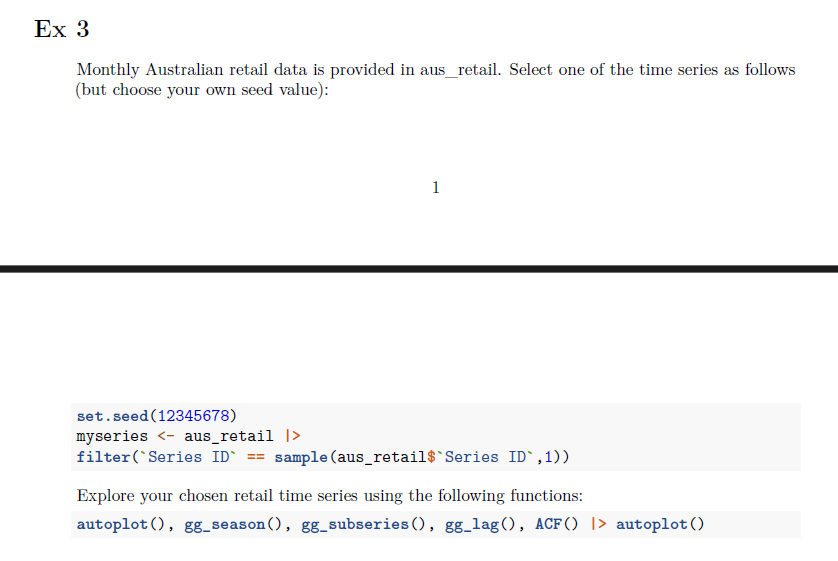

In [16]:
# Load Australian retail dataset
internet_path = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/aus_retail.csv"
aus_retail = pd.read_csv(internet_path)

# Display the first few rows of the dataset
print(aus_retail.head())

HTTPError: HTTP Error 404: Not Found